In [85]:
#Import Librairies
import pandas as pd
import numpy as ny
# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
# import KMeans from sklearn
from sklearn.cluster import KMeans
# Import silhouette score
from sklearn.metrics import silhouette_score
# Import Standard Scaler
from sklearn.preprocessing import StandardScaler


In [86]:
dataset = pd.read_csv('/Volumes/My Shared Files/DataEngineer/Ressources/Unsupervised_Machine_Learning/Projects_Unsupervised_Machine_Learning/Uber_Pickups/uber-trip-data/uber-raw-data-apr14.csv')

print('Shape')
print(dataset.shape)
print()
print('Global stat')
print(dataset.describe(include='all'))
print()
print('Percentage Empty')
print(dataset.isnull().sum()/dataset.shape[0])

Shape
(564516, 4)

Global stat
                Date/Time            Lat            Lon    Base
count              564516  564516.000000  564516.000000  564516
unique              41999            NaN            NaN       5
top     4/7/2014 20:21:00            NaN            NaN  B02682
freq                   97            NaN            NaN  227808
mean                  NaN      40.740005     -73.976817     NaN
std                   NaN       0.036083       0.050426     NaN
min                   NaN      40.072900     -74.773300     NaN
25%                   NaN      40.722500     -73.997700     NaN
50%                   NaN      40.742500     -73.984800     NaN
75%                   NaN      40.760700     -73.970000     NaN
max                   NaN      42.116600     -72.066600     NaN

Percentage Empty
Date/Time    0.0
Lat          0.0
Lon          0.0
Base         0.0
dtype: float64


In [87]:
#Transform Date/Time in usefull column
dataset['Date_Time_date_time'] = pd.to_datetime(dataset['Date/Time'])
dataset['year'] = dataset['Date_Time_date_time'].dt.year
dataset['month'] = dataset['Date_Time_date_time'].dt.month
dataset['day'] = dataset['Date_Time_date_time'].dt.day
dataset['weekday'] = dataset['Date_Time_date_time'].dt.day_name()
dataset['hour'] = dataset['Date_Time_date_time'].dt.hour
dataset['minute'] = dataset['Date_Time_date_time'].dt.minute
dataset = dataset.drop(['Date_Time_date_time'], axis = 1)
dataset.head()

,Date/Time,Lat,Lon,Base,year,month,day,weekday,hour,minute
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512,2014,4,1,Tuesday,0,11
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512,2014,4,1,Tuesday,0,17
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512,2014,4,1,Tuesday,0,21
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512,2014,4,1,Tuesday,0,28
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512,2014,4,1,Tuesday,0,33


In [88]:
dataset_day1 = dataset.loc[dataset['day']==1,:]
dataset_day1_10h = dataset_day1.loc[dataset['hour'] == 10,:]

In [89]:
#General view of the data
fig = px.scatter_map(data_frame=dataset_day1, 
				lat = 'Lat',
				lon = 'Lon',
				color = 'hour',
				title='Uber pickups',
		zoom=10,)

fig.show()

# For one hour of one day

In [90]:
dataset_day1 = dataset.loc[dataset['day']==1,:]
dataset_day1_10h = dataset_day1.loc[dataset['hour'] == 10,:]

In [91]:
# Initialize StandardScaler
sc = StandardScaler()

X = dataset_day1_10h.loc[:, ['Lat', 'Lon']]

# Apply StandardScaler to X
X = sc.fit_transform(X)

# Visualize first five rows
X[:5]

array([[ 1.10527329,  0.0570841 ],
       [ 0.60398655,  0.23577567],
       [ 1.02748741,  1.71274847],
       [-0.04999097, -0.15481564],
       [-0.04711001, -0.05993516]])

WCSS for K=1 --> 954.0
WCSS for K=2 --> 643.3283327324267
WCSS for K=3 --> 493.95177692263496
WCSS for K=4 --> 308.277360479831
WCSS for K=5 --> 252.6296499613869
WCSS for K=6 --> 204.26594574580463
WCSS for K=7 --> 149.4439061234264
WCSS for K=8 --> 140.8813615536754
WCSS for K=9 --> 121.841289266861
WCSS for K=10 --> 87.95424953534538


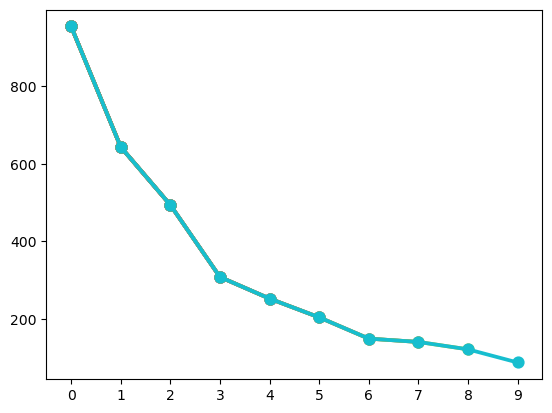

In [92]:
# Computer elbow score
# Cllect the Within-sum-of-square (wcss) for each value K
# Let's use .inertia_ parameter to get the within sum of square value for each value K
wcss =  []
k = []
for i in range (1,11):
    kmeans = KMeans(n_clusters= i, random_state = 0, n_init = 'auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    k.append(i)
    print("WCSS for K={} --> {}".format(i, wcss[-1]))
    sns.pointplot(wcss)


Silhouette score for K=2 is 0.43892332054908406
Silhouette score for K=3 is 0.4529106507486494
Silhouette score for K=4 is 0.4755003482285656
Silhouette score for K=5 is 0.45748192841471114
Silhouette score for K=6 is 0.4846084364701372
Silhouette score for K=7 is 0.4902718224262205
Silhouette score for K=8 is 0.4321906889959892
Silhouette score for K=9 is 0.42991821519433265
Silhouette score for K=10 is 0.4456243269404663


<Axes: >

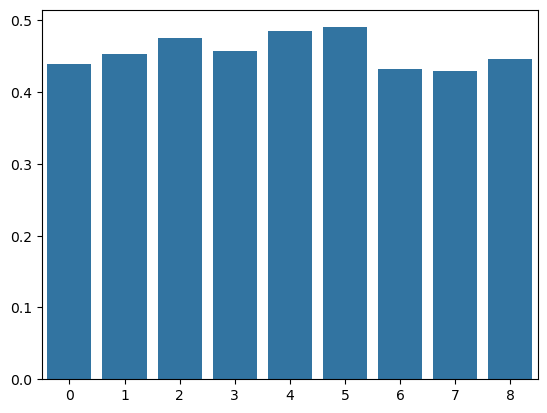

In [93]:
# Computer mean silhouette score
sil = []
k = []

## Careful, you need to start at i=2 as silhouette score cannot accept less than 2 labels
for i in range (2,11):
    kmeans = KMeans(n_clusters= i, random_state = 0, n_init = 'auto')
    kmeans.fit(X)
    sil.append(silhouette_score(X, kmeans.predict(X)))
    k.append(i)
    print("Silhouette score for K={} is {}".format(i, sil[-1]))

sns.barplot(sil)

In [94]:
# Instanciate KMeans
kmeans = KMeans(n_clusters=4)

# Fit on data
kmeans.fit(X)

# Visualize with plotly

dataset_day1_10h.loc[:,'Cluster_KMeans'] = kmeans.predict(X)
fig= px.scatter_map(data_frame=dataset_day1_10h, 
				lat = 'Lat',
				lon = 'Lon',
				color = 'Cluster_KMeans',
				title='Uber pickups',
		zoom=10)
fig.show()


/var/folders/p7/np24gf2d0mx6bl_nx8_y4yxh0000gn/T/ipykernel_1167/515038764.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# For one day

WCSS calculation for hour:  0
WCSS for K=1 --> 276.0
WCSS for K=2 --> 133.82348156255742
WCSS for K=3 --> 74.85164239170712
WCSS for K=4 --> 50.991175580601436
WCSS for K=5 --> 44.32719706250155
WCSS for K=6 --> 36.936507261578456
WCSS for K=7 --> 26.64027892575308
WCSS for K=8 --> 25.26353431463156
WCSS for K=9 --> 21.01664434910299
WCSS for K=10 --> 17.40310308054305
WCSS calculation for hour:  1
WCSS for K=1 --> 131.99999999999997
WCSS for K=2 --> 92.01654408631222
WCSS for K=3 --> 43.19814157186664
WCSS for K=4 --> 26.044341088232525
WCSS for K=5 --> 18.95846586589803
WCSS for K=6 --> 15.953329393361958
WCSS for K=7 --> 10.465892883272344
WCSS for K=8 --> 7.335026220753358
WCSS for K=9 --> 6.1610242149003245
WCSS for K=10 --> 5.396540926580662
WCSS calculation for hour:  2
WCSS for K=1 --> 105.99999999999999
WCSS for K=2 --> 65.55683476985297
WCSS for K=3 --> 36.69742501536598
WCSS for K=4 --> 25.282288068886064
WCSS for K=5 --> 14.30042996028347
WCSS for K=6 --> 13.017378554791833

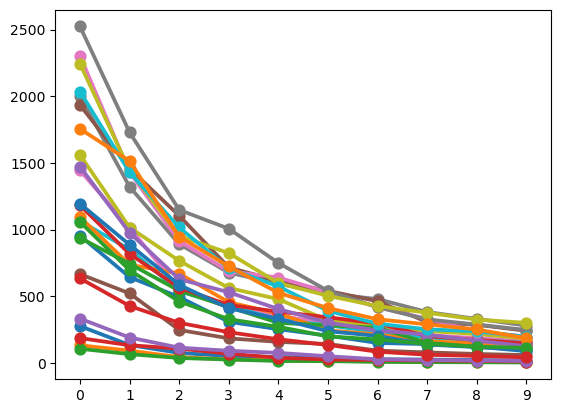

In [95]:
# Initialize StandardScaler
# StandardScaler will substract mean and divide by standard deviation to each observation
sc = StandardScaler()

dataset_day1_dic = dict()

for hour in dataset_day1.hour.unique():
	dataset_day1_dic[hour] = dataset_day1.loc[dataset['hour'] == hour,:]
	X = dataset_day1_dic[hour].loc[:, ['Lat', 'Lon']]
	# Apply StandardScaler to X
	X = sc.fit_transform(X)
	wcss =  []
	k = []
	print("WCSS calculation for hour: ", hour)
	for i in range (1,11):
		kmeans = KMeans(n_clusters= i, random_state = 0, n_init = 'auto')
		kmeans.fit(X)
		wcss.append(kmeans.inertia_)
		k.append(i)
		print("WCSS for K={} --> {}".format(i, wcss[-1]))
	sns.pointplot(wcss)

Silhouette score for hour:  0
Silhouette score for K=2 is 0.7344885937594278
Silhouette score for K=3 is 0.46438470796862147
Silhouette score for K=4 is 0.47636495714683297
Silhouette score for K=5 is 0.45648983530619597
Silhouette score for K=6 is 0.3764519651468266
Silhouette score for K=7 is 0.45911824928771844
Silhouette score for K=8 is 0.4294613191674919
Silhouette score for K=9 is 0.43781006347602097
Silhouette score for K=10 is 0.48673366465888357
Silhouette score for hour:  1
Silhouette score for K=2 is 0.39295500121819504
Silhouette score for K=3 is 0.6066243381030031
Silhouette score for K=4 is 0.49236771144162145
Silhouette score for K=5 is 0.49918627826474815
Silhouette score for K=6 is 0.4257580993011971
Silhouette score for K=7 is 0.4546128329331287
Silhouette score for K=8 is 0.4471477048602593
Silhouette score for K=9 is 0.47154913164786466
Silhouette score for K=10 is 0.4710693608425999
Silhouette score for hour:  2
Silhouette score for K=2 is 0.7399104863056637
Silho

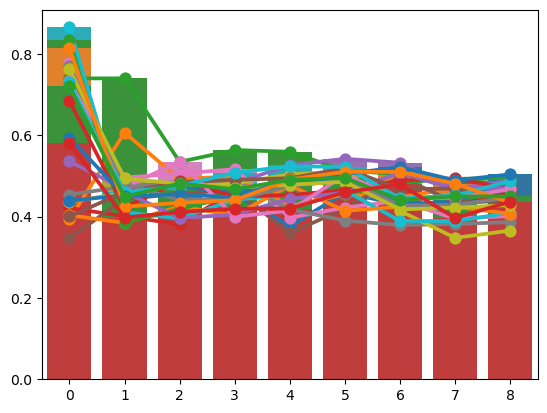

In [96]:
for hour in dataset_day1.hour.unique():
	X = dataset_day1_dic[hour].loc[:, ['Lat', 'Lon']]
	# Apply StandardScaler to X
	X = sc.fit_transform(X)
	# Computer mean silhouette score
	sil = []
	k = []
	print("Silhouette score for hour: ", hour)

	for i in range (2,11):
		kmeans = KMeans(n_clusters= i, random_state = 0, n_init = 'auto')
		kmeans.fit(X)
		sil.append(silhouette_score(X, kmeans.predict(X)))
		k.append(i)
		print("Silhouette score for K={} is {}".format(i, sil[-1]))

	sns.barplot(sil)
	sns.pointplot(sil)


In [99]:
# Instanciate KMeans
n_clusters =6 
kmeans = KMeans(n_clusters=n_clusters)

center_list = []
# Visualize with plotly
for hour in dataset_day1.hour.unique():
	X = dataset_day1_dic[hour].loc[:, ['Lat', 'Lon']]
	# Apply StandardScaler to X
	X = sc.fit_transform(X)
	# Fit on data
	kmeans.fit(X)
	for cluster in range(0,n_clusters):
		center_list.append(np.r_[sc.inverse_transform(kmeans.cluster_centers_)[cluster], hour, cluster].tolist())				 
center=pd.DataFrame(center_list, columns=['Lat', 'Lon','hour', 'cluster'])
fig=px.scatter_map(data_frame=center, 
						lat = 'Lat',
						lon = 'Lon',
						title='Uber pickups centroids per cluster',
						color='cluster',
				zoom=10)
	
fig.show()
fig=px.scatter_map(data_frame=center, 
						lat = 'Lat',
						lon = 'Lon',
						title='Uber pickups centroids per hour',
						color='hour',
				zoom=10)
	
fig.show()


In [98]:
# import DBSCAN from sklearn and numpy
from sklearn.cluster import DBSCAN

dataset_day1 = dataset.loc[dataset['day']==1,:]
dataset_day1_10h = dataset_day1.loc[dataset['hour'] == 10,:]


X = dataset_day1_10h.loc[:, ['Lat', 'Lon']]
	# Apply StandardScaler to X
X = sc.fit_transform(X)

# Instanciate DBSCAN
db = DBSCAN(eps=0.1, min_samples=4, metric="manhattan", algorithm="brute")

# Fit on data
db.fit(X)

# Visualize with plotly
dataset_day1_10h.loc[:,'Cluster_DBSCAN']= db.labels_
fig= px.scatter_map(data_frame=dataset_day1_10h.loc[dataset_day1_10h['Cluster_DBSCAN'] != -1,:], 
				lat = 'Lat',
				lon = 'Lon',
				color = 'Cluster_DBSCAN',
				title='Uber pickups',
		zoom=10)
fig.show()

/var/folders/p7/np24gf2d0mx6bl_nx8_y4yxh0000gn/T/ipykernel_1167/4229316381.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
regarder Yellow brick pour afficher les deux scores
from yellowbrick.features import ParallelCoordinates

visualizer = ParallelCoordinates()
visualizer.fit_transform(X, y)
visualizer.show()


regarder Yellowbrick pour voir la répartition des clusters